#  NOTEBOOK 02 — Feature Analysis


# BLOCK NO -> 01

In [1]:
# 1. IMPORT AND LOAD DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot setting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load Dataset
df = pd.read_csv('../DATA/raw/Employee Attrition Prediction Dataset.csv')
print("✅ Dataset loaded successfully.")
print(f"shape: {df.shape[0]} rows * {df.shape[1]} columns")

✅ Dataset loaded successfully.
shape: 1470 rows * 35 columns


# BLOCK NO -> 02

In [2]:
# 2. FEATURE TYPE SEPARATION
print("=" * 60)
print("FEATURE TYPE SEPARATION")
print("=" * 60)

# Numerical features (continuous)
numerical_features = ['Age', 'DailyRate', 'Distance From Home', 'Hourly Rate', 
                      'Monthly Income', 'Monthly Rate', 'Num Companies Worked',
                      'Percent Salary Hike', 'Total Working Years', 
                      'Training Times LastYear', 'Years At Company', 
                      'Years In CurrentRole', 'Years Since Last Promotion', 
                      'Years With Curr Manager']

# Ordinal features (ordered categorical)
ordinal_features = ['Education', 'Environment Satisfaction', 'Job Involvement', 
                   'Job Level', 'Job Satisfaction', 'Performance Rating',
                   'Relationship Satisfaction', 'Stock Option Level', 
                   'Work Life Balance']

# Categorical features (nominal)
categorical_features = ['BusinessTravel', 'Department', 'Education Field', 
                       'Gender', 'JobRole', 'Marital Status', 'OverTime']

# Constant/ID columns (to ignore)
ignore_cols = ['Employee Count', 'Employee Number', 'Over 18', 'Standard Hours']

print(f"\n✅ Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"\n✅ Ordinal Fetures ({len(ordinal_features)}) {ordinal_features}")
print(f"\n✅ Categorial Features ({len(categorical_features)}) {categorical_features}")
print(f"\n✅ Ignored Columns ({len(ignore_cols)}) {ignore_cols}")

FEATURE TYPE SEPARATION

✅ Numerical Features (14): ['Age', 'DailyRate', 'Distance From Home', 'Hourly Rate', 'Monthly Income', 'Monthly Rate', 'Num Companies Worked', 'Percent Salary Hike', 'Total Working Years', 'Training Times LastYear', 'Years At Company', 'Years In CurrentRole', 'Years Since Last Promotion', 'Years With Curr Manager']

✅ Ordinal Fetures (9) ['Education', 'Environment Satisfaction', 'Job Involvement', 'Job Level', 'Job Satisfaction', 'Performance Rating', 'Relationship Satisfaction', 'Stock Option Level', 'Work Life Balance']

✅ Categorial Features (7) ['BusinessTravel', 'Department', 'Education Field', 'Gender', 'JobRole', 'Marital Status', 'OverTime']

✅ Ignored Columns (4) ['Employee Count', 'Employee Number', 'Over 18', 'Standard Hours']


# BLOCK NO -> 03

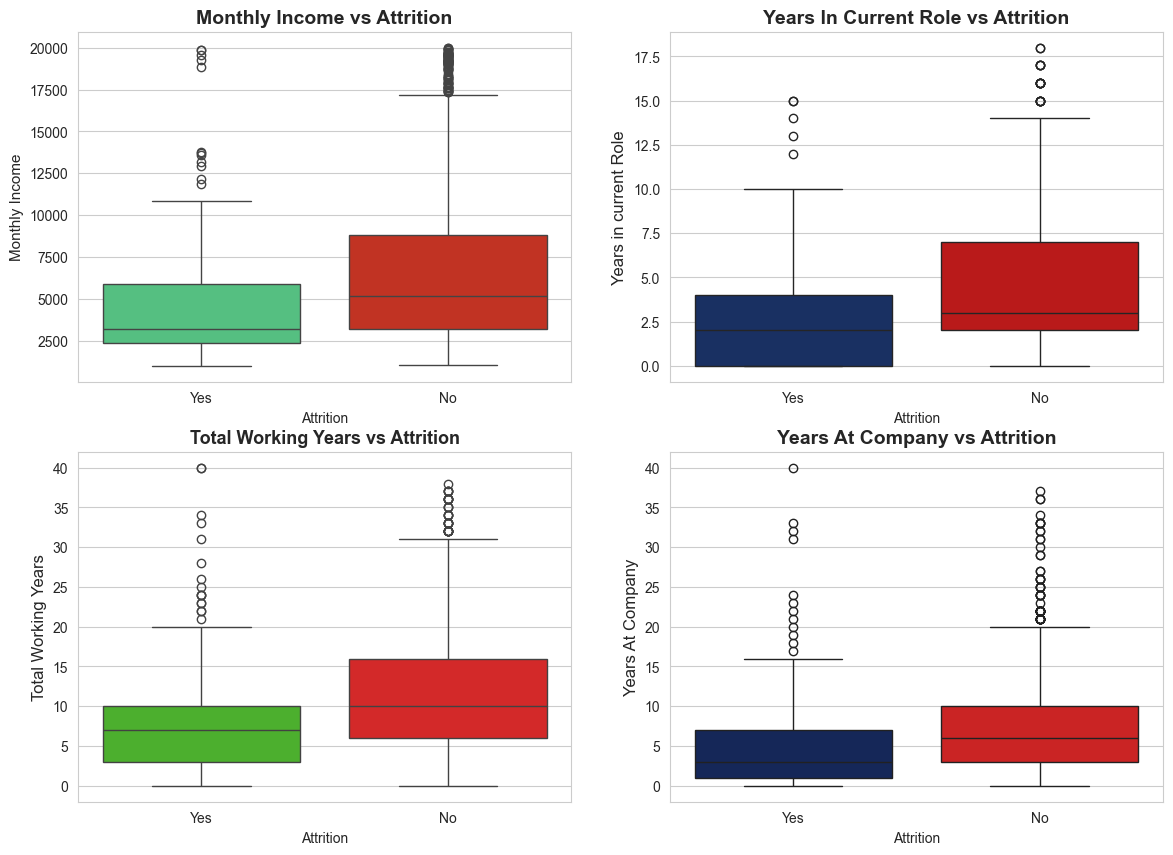

Lower Monthly Income and fewer years of experience correlate with higher attrition rates.
Employee with less tenure in current role show increased likelihood of leaving the organization.


In [3]:
# 3. NUMERICAL ANALYSIS - GROUP 01 (Income & Years)
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

# Montly Income vs Attriction
sns.boxplot(data = df, x = 'Attrition', y = 'Monthly Income', ax = axes[0, 0], palette = ["#43d17e", "#db1e09"])
axes[0, 0].set_title('Monthly Income vs Attrition', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_ylabel('Monthly Income', fontsize = 11)

# Years in current role vs attrition
sns.boxplot(data = df, x = 'Attrition', y = 'Years In CurrentRole', ax = axes[0, 1], palette = ["#0d2c6e", '#D30000'])
axes[0, 1].set_title("Years In Current Role vs Attrition", fontsize = 14, fontweight = 'bold')
axes[0, 1].set_ylabel('Years in current Role', fontsize = 12)

# Total Working Years vs Attrition
sns.boxplot(data = df, x = 'Attrition', y = 'Total Working Years', ax = axes[1, 0], palette = ["#41C419", "#F00C0C"])
axes[1, 0].set_title('Total Working Years vs Attrition', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Total Working Years', fontsize = 12)

# Years At Company vs Attrition
sns.boxplot(data = df, x = 'Attrition', y = 'Years At Company', ax = axes[1, 1], palette = ["#0A2263", "#E60808"])
axes[1, 1].set_title('Years At Company vs Attrition', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_ylabel('Years At Company', fontsize = 12)

plt.tight_layout
plt.show()

print("Lower Monthly Income and fewer years of experience correlate with higher attrition rates.")
print("Employee with less tenure in current role show increased likelihood of leaving the organization.")

# BLOCK NO -> 04

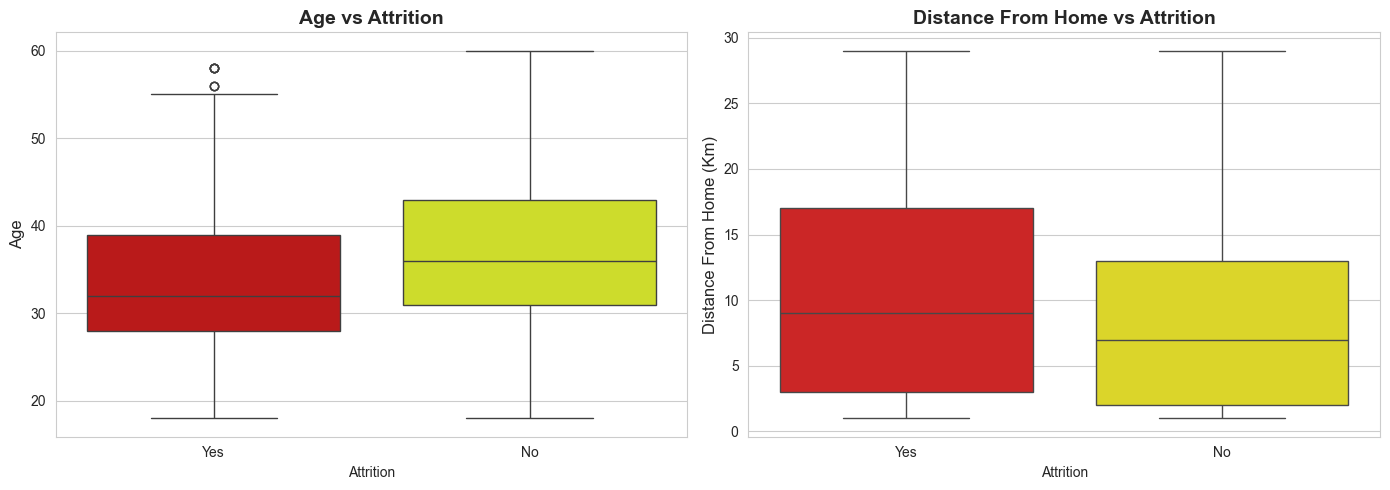

Younger Employees show higher attrition Tendency comaprec to older, more experienced workers.
Greater distance from home shows slight correlation with increased attrition probability.


In [4]:
# 4. Numerical Analysis - Group 02 (Age vs Distance)
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Age vs Attrition
sns.boxplot(data = df, x = 'Attrition', y = 'Age', ax = axes[0], palette = ['#D30000', "#E6F90F"])
axes[0].set_title('Age vs Attrition', fontsize = 14, fontweight = 'bold')
axes[0].set_ylabel('Age', fontsize = 12)

# Distance From Home vs Attrition
sns.boxplot(data = df, x = 'Attrition', y = 'Distance From Home', ax = axes[1], palette = ["#E60B0B", "#F9F10C"])
axes[1].set_title("Distance From Home vs Attrition", fontsize = 14, fontweight = 'bold')
axes[1].set_ylabel('Distance From Home (Km)', fontsize = 12)

plt.tight_layout()
plt.show()

print("Younger Employees show higher attrition Tendency comaprec to older, more experienced workers.")
print("Greater distance from home shows slight correlation with increased attrition probability.")

# BLOCK NO -> 05

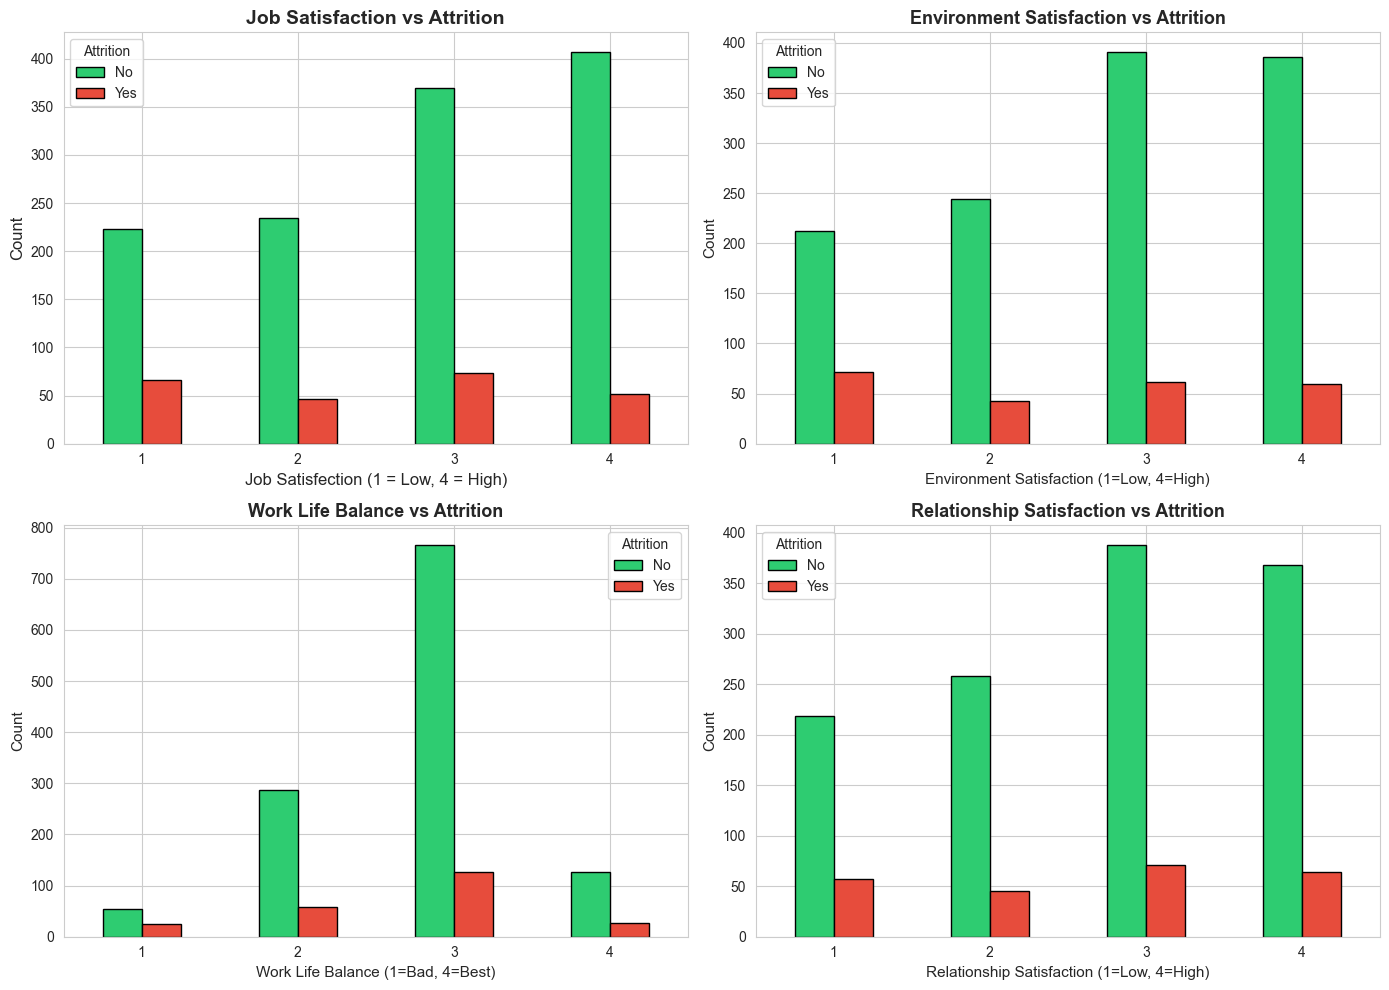

Lower satisfaction scores across all metrics strongly correlate with higher attrition rates.
Job satisfaction and work-life balance appear to be critical factors influencing employee retention.


In [5]:
# 5. ORDINAL ANALYSIS - GROUP 01 (Satisfection Metrics)

fig, axes = plt.subplots(2, 2, figsize = (14, 10))

# Job Satisfection vs Attrition
job_sat = df.groupby(['Job Satisfaction', 'Attrition']).size().unstack(fill_value = 0)
job_sat.plot(kind = 'bar', ax = axes[0, 0], color = ['#2ecc71', '#e74c3c'], edgecolor = '#000000')
axes[0, 0].set_title('Job Satisfaction vs Attrition', fontsize = 14, fontweight = 'bold')
axes[0, 0].set_xlabel('Job Satisfection (1 = Low, 4 = High)', fontsize = 12)
axes[0, 0].set_ylabel('Count', fontsize = 12)
axes[0, 0].legend(['No', 'Yes'], title = 'Attrition')
axes[0, 0].tick_params(axis = 'x', rotation = 0)

# Environment Satisfaction vs Attrition
env_sat = df.groupby(['Environment Satisfaction', 'Attrition']).size().unstack(fill_value=0)
env_sat.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 1].set_title('Environment Satisfaction vs Attrition', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Environment Satisfaction (1=Low, 4=High)', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].legend(['No', 'Yes'], title='Attrition')
axes[0, 1].tick_params(axis='x', rotation=0)

# Work Life Balance vs Attrition
wlb = df.groupby(['Work Life Balance', 'Attrition']).size().unstack(fill_value=0)
wlb.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 0].set_title('Work Life Balance vs Attrition', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Work Life Balance (1=Bad, 4=Best)', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].legend(['No', 'Yes'], title='Attrition')
axes[1, 0].tick_params(axis='x', rotation=0)

# Relationship Satisfaction vs Attrition
rel_sat = df.groupby(['Relationship Satisfaction', 'Attrition']).size().unstack(fill_value=0)
rel_sat.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1, 1].set_title('Relationship Satisfaction vs Attrition', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Relationship Satisfaction (1=Low, 4=High)', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].legend(['No', 'Yes'], title='Attrition')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Lower satisfaction scores across all metrics strongly correlate with higher attrition rates.")
print("Job satisfaction and work-life balance appear to be critical factors influencing employee retention.")

# BLOCK NO -> 06 

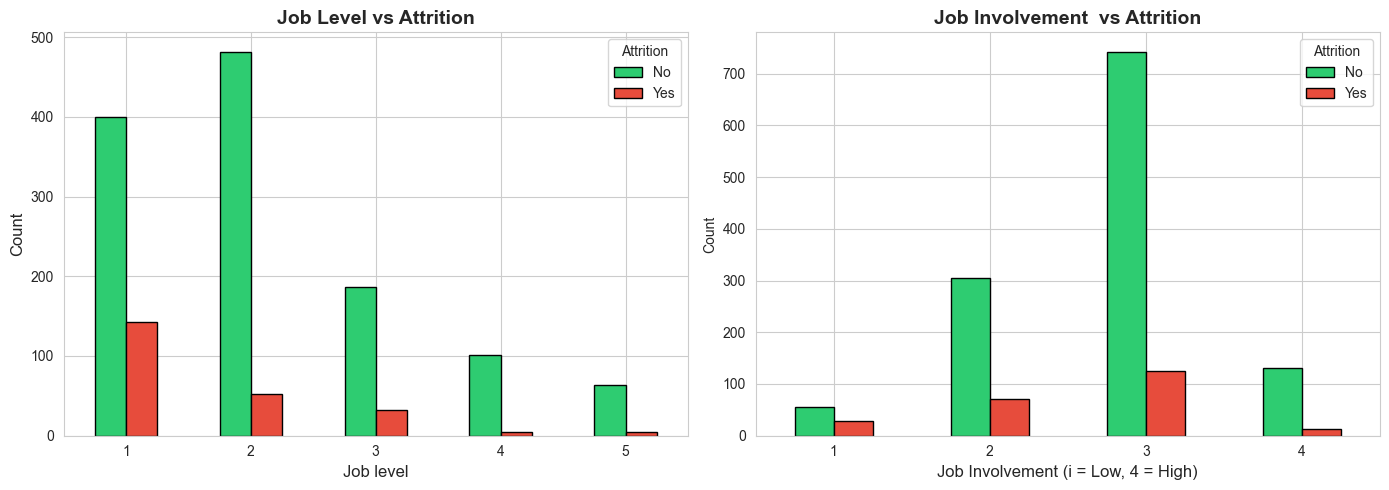

lower job levels show higher attrition; senior positives have better retaintion rates.
Low job involvement is a strong predictor  of attrition in decision Tree models.


In [6]:
# 6. ORDINAL ANALYSIS - GROUP 02 (Job level and involvement)
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Job Lebel vs Attrition
job_level = df.groupby(['Job Level', 'Attrition']).size().unstack(fill_value = 0)
job_level.plot(kind = 'bar', ax = axes[0], color = ['#2ecc71', '#e74c3c'], edgecolor = '#000000')
axes[0].set_title('Job Level vs Attrition', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Job level', fontsize = 12)
axes[0].set_ylabel('Count', fontsize = 12)
axes[0].legend(['No', 'Yes'], title = 'Attrition')
axes[0].tick_params(axis = 'x', rotation = 0)

# Job involvement vs Attrition
job_inv = df.groupby(['Job Involvement', 'Attrition']).size().unstack(fill_value = 0)
job_inv.plot(kind = 'bar', ax = axes[1], color = ['#2ecc71', '#e74c3c'], edgecolor = '#000000')
axes[1].set_title('Job Involvement  vs Attrition', fontsize = 14, fontweight = 'bold')
axes[1].set_xlabel('Job Involvement (i = Low, 4 = High)', fontsize = 12)
axes[1].set_ylabel('Count', fontweight = 12)
axes[1].legend(['No', 'Yes'], title = 'Attrition')
axes[1].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.show()

print("lower job levels show higher attrition; senior positives have better retaintion rates.")
print("Low job involvement is a strong predictor  of attrition in decision Tree models.")

# BLOCK NO -> 07

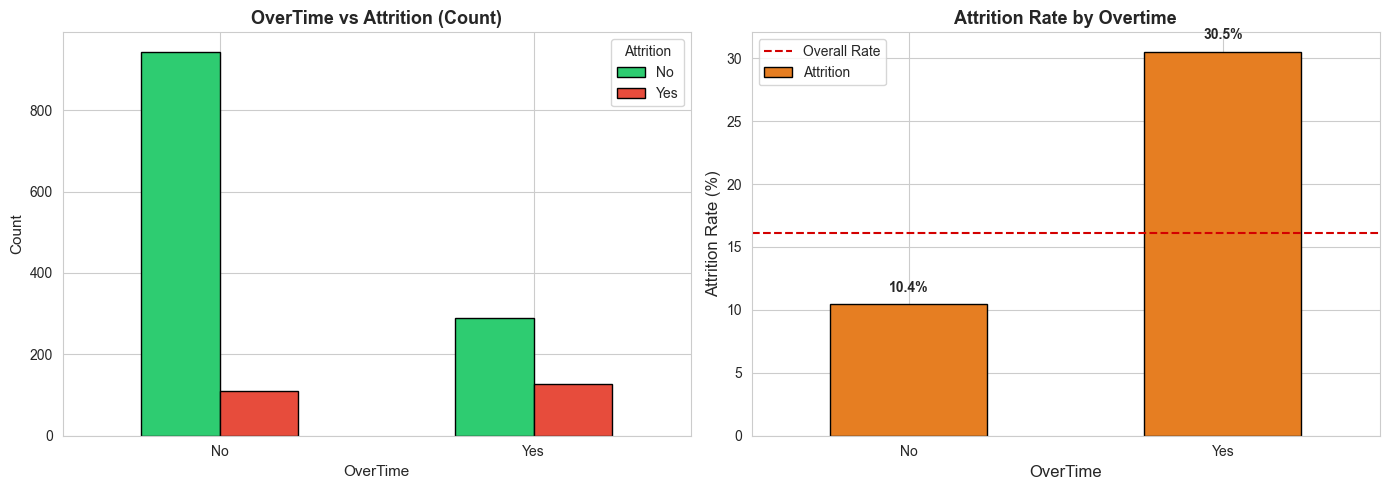

Employees working overtime show significantly higher attrition rates compared to those who don't.
This is a critical categorical feature for Random Forest classification models.


In [7]:
# 7. CATEGORICAL ANALYSIS – OVERTIME
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OverTime Distribution by Attrition (Count)
overtime_data = df.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
overtime_data.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('OverTime vs Attrition (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('OverTime', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['No', 'Yes'], title='Attrition')
axes[0].tick_params(axis='x', rotation=0)

# Over time attrition rate
overtime_pct = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
overtime_pct.plot(kind = 'bar', ax = axes[1], color ='#e67e22', edgecolor = '#000000')
axes[1].set_title('Attrition Rate by Overtime', fontsize = 13, fontweight = 'bold')
axes[1].set_xlabel('OverTime', fontsize = 12)
axes[1].set_ylabel('Attrition Rate (%)', fontsize = 12)
axes[1].tick_params(axis = 'x', rotation = 0)
axes[1].axhline(y = df['Attrition'].value_counts(normalize = True)['Yes'] * 100,
                color = '#D30000', linestyle = '--', label = 'Overall Rate')
axes[1].legend()

for i, v in enumerate(overtime_pct):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha = 'center', fontweight = 'bold')

plt.tight_layout()
plt.show()

print("Employees working overtime show significantly higher attrition rates compared to those who don't.")
print("This is a critical categorical feature for Random Forest classification models.")

# BLOCK NO -> 08

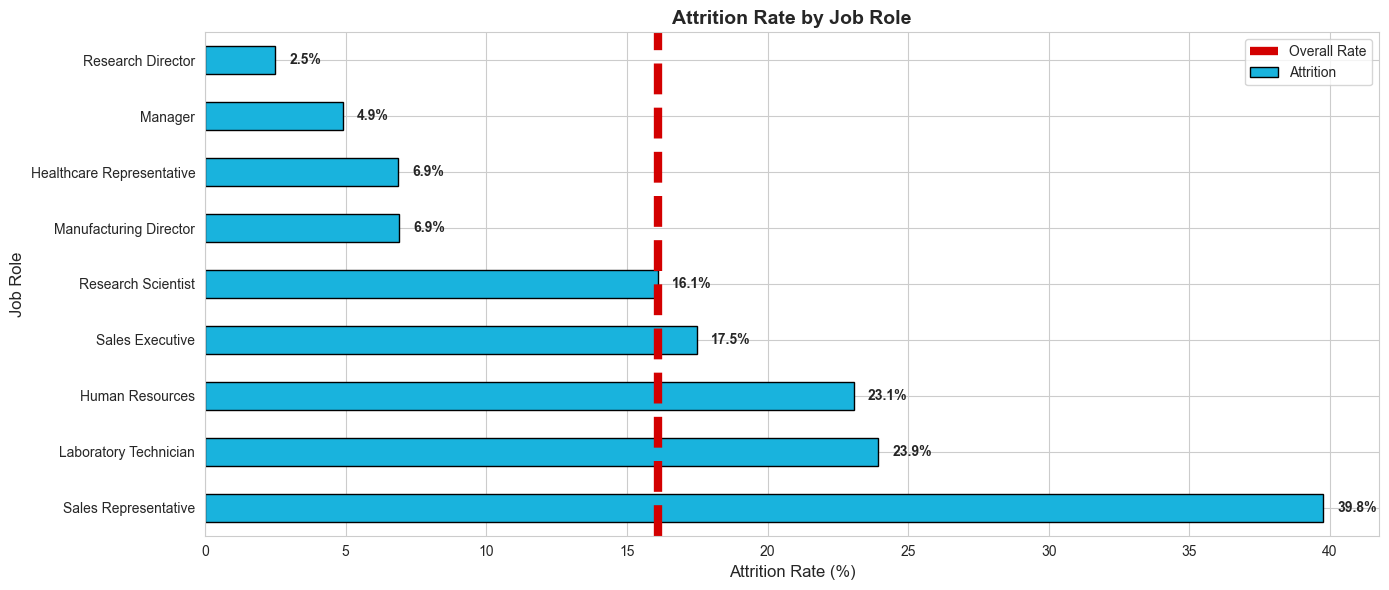

Sales Representatives and Laboratory Technicians exhibit the highest attrition rates among all job roles.
Decision Trees will effectively split on this categorical feature to improve prediction accuracy.


In [8]:
# 8. CATEGORIAL ANALYSIS - JOBROLE

plt.figure(figsize = (14, 6))

# Jobrole attrition rate
jobrole_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending = False)

jobrole_attrition.plot(kind = 'barh', color = "#19B3DD", edgecolor = '#000000')
plt.title('Attrition Rate by Job Role', fontsize = 14, fontweight = 'bold')
plt.xlabel('Attrition Rate (%)', fontsize = 12)
plt.ylabel('Job Role', fontsize = 12)
plt.axvline(x =df['Attrition'].value_counts(normalize = True)['Yes'] * 100, color = '#D30000', linestyle = '--', linewidth = 6, label = 'Overall Rate')
plt.legend()

for i, v in enumerate(jobrole_attrition):
    plt.text(v + 0.5, i, f'{v:.1f}%', va = 'center', fontweight = 'bold', fontsize = 10)

plt.tight_layout()
plt.show()

print("Sales Representatives and Laboratory Technicians exhibit the highest attrition rates among all job roles.")
print("Decision Trees will effectively split on this categorical feature to improve prediction accuracy.")

# BLOCK NO -> 09

In [9]:
# 9. SUMMARY STATISTICS
print("="*60)
print("SUMMARY STATISTICS: ATTRITION vs KEY FEATURES")
print("="*60)

# Numerical features grouped by Attrition
key_numerical = ['Age', 'Monthly Income', 'Years At Company', 'Years In CurrentRole', 
                'Total Working Years', 'Distance From Home']

print("\nNUMERICAL FEATURES BY ATTRITION:")
print("-" * 60)
summary = df.groupby('Attrition')[key_numerical].mean().round(2)
print(summary)

# Attrition rate by key categorical features
print("\n" + "-"*60)
print("ATTRITION RATE BY KEY CATEGORICAL FEATURES:")
print("-" * 60)

for feature in ['OverTime', 'Department', 'JobRole', 'Marital Status']:
    attrition_rate = df.groupby(feature)['Attrition'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).round(2)
    print(f"\n{feature}:")
    print(attrition_rate.sort_values(ascending = False))

# Attrition rate by ordinal satisfaction
print("\n" + "="*60)
print("ATTRITION RATE BY SATISFACTION LEVELS:")
print("=" * 60)

for feature in ['Job Satisfaction', 'Work Life Balance', 'Environment Satisfaction']:
    attrition_rate = df.groupby(feature)['Attrition'].apply(lambda x: (x == 'Yes').sum() / len(x) * 100).round(2)
    print(f"\n{feature}:")
    print(attrition_rate)

SUMMARY STATISTICS: ATTRITION vs KEY FEATURES

NUMERICAL FEATURES BY ATTRITION:
------------------------------------------------------------
             Age  Monthly Income  Years At Company  Years In CurrentRole  \
Attrition                                                                  
No         37.56         6832.74              7.37                  4.48   
Yes        33.61         4787.09              5.13                  2.90   

           Total Working Years  Distance From Home  
Attrition                                           
No                       11.86                8.92  
Yes                       8.24               10.63  

------------------------------------------------------------
ATTRITION RATE BY KEY CATEGORICAL FEATURES:
------------------------------------------------------------

OverTime:
OverTime
Yes    30.53
No     10.44
Name: Attrition, dtype: float64

Department:
Department
Sales                     20.63
Human Resources           19.05
Research 

# BLOCK NO -> 10

In [10]:
# 10. KEY INSIGHTS (MARKDOWN)
print("="*60)
print("🔍 KEY INSIGHTS FROM FEATURE ANALYSIS")
print("="*60)

print("\n📊 NUMERICAL FEATURES:")
print("-" * 60)
print("• Lower Monthly Income → Higher Attrition")
print("• Fewer Years in Current Role → Higher Attrition")
print("• Younger Age → Higher Attrition")
print("• Greater Distance From Home → Moderate Attrition Impact")
print("• Less Total Working Years → Higher Attrition")

print("\n📈 ORDINAL FEATURES:")
print("-" * 60)
print("• Lower Job Satisfaction → Significantly Higher Attrition")
print("• Poor Work Life Balance → Higher Attrition")
print("• Low Environment Satisfaction → Higher Attrition")
print("• Lower Job Level → Higher Attrition")
print("• Low Job Involvement → Strong Attrition Predictor")

print("\n🏷️ CATEGORICAL FEATURES:")
print("-" * 60)
print("• OverTime = Yes → ~30% Attrition Rate (Critical Feature)")
print("• Sales Representatives → Highest Attrition by Job Role")
print("• Laboratory Technicians → Second Highest Attrition")
print("• Single Employees → Higher Attrition than Married/Divorced")

print("\n" + "="*60)
print("🎯 MODELING IMPLICATIONS FOR DECISION TREES & RANDOM FORESTS")
print("="*60)
print("✅ Strong predictive features identified: OverTime, Monthly Income, Job Satisfaction")
print("✅ Multiple feature types (numerical, ordinal, categorical) suitable for tree-based models")
print("✅ Clear decision boundaries visible in categorical features (OverTime, JobRole)")
print("✅ Feature importance ranking will validate these findings in Random Forest")
print("✅ Class imbalance must be addressed before model training")

print("\n" + "="*60)
print("➡️ NEXT STEPS")
print("="*60)
print("→ Notebook 03: Data Preprocessing & Feature Engineering")
print("→ Encode categorical variables for model compatibility")
print("→ Handle class imbalance (SMOTE/Class Weights)")
print("→ Feature scaling for numerical variables")
print("→ Train-test split preparation")
print("="*60)

🔍 KEY INSIGHTS FROM FEATURE ANALYSIS

📊 NUMERICAL FEATURES:
------------------------------------------------------------
• Lower Monthly Income → Higher Attrition
• Fewer Years in Current Role → Higher Attrition
• Younger Age → Higher Attrition
• Greater Distance From Home → Moderate Attrition Impact
• Less Total Working Years → Higher Attrition

📈 ORDINAL FEATURES:
------------------------------------------------------------
• Lower Job Satisfaction → Significantly Higher Attrition
• Poor Work Life Balance → Higher Attrition
• Low Environment Satisfaction → Higher Attrition
• Lower Job Level → Higher Attrition
• Low Job Involvement → Strong Attrition Predictor

🏷️ CATEGORICAL FEATURES:
------------------------------------------------------------
• OverTime = Yes → ~30% Attrition Rate (Critical Feature)
• Sales Representatives → Highest Attrition by Job Role
• Laboratory Technicians → Second Highest Attrition
• Single Employees → Higher Attrition than Married/Divorced

🎯 MODELING IMPLI

# “This notebook explores feature–attrition relationships using univariate and bivariate analysis. Multiple behavioral, satisfaction, and workload-related features show strong association with attrition.”